
### `N-Gram Analysis` (Yoruba Text)

N-gram analysis is a basic yet powerful technique in Natural Language Processing (NLP). It involves breaking text into sequences of `n` items, usually words, to understand patterns, frequency, and co-occurrence. Examples include:
- **Unigram** (n=1): single words
- **Bigram** (n=2): pairs of words
- **Trigram** (n=3): triples of words
- ...and so on.

In this notebook, we’ll apply n-gram analysis to Yoruba-language text. We use the Yankari dataset (https://huggingface.co/datasets/acflp/YANKARI) as the reference corpus, extract n-grams of varying sizes, compute their probabilities, and use them to score new texts based on how likely they are under the model.

In [132]:
# import libraries
import json
import math
import regex as re
import unicodedata
from collections import Counter
from datasets import load_dataset
import pandas as pd
import os
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

In [133]:
# Load the reference corpus into a pandas DataFrame
dataset = load_dataset("acflp/YANKARI", verification_mode="basic_checks", trust_remote_code=True)

reference_text = pd.DataFrame(dataset["train"])[['text']]

# Display the first 5 rows of the DataFrame
print(reference_text.head())

                                                text
0  O ma ṣe o! Ijamba ọkọ ofurufu gba ẹmi eeyan ma...
1  Ọbasanjọ ni ki ijọba Naijiria lọ gba amọran lo...
2  Awọn ajinigbe ha ni Kwara, ọkan ku: Agbarijọ a...
3  AbdulRazaq san gbogbo gbese ti Gomina Ahmẹd jẹ...
4  Ọmọ ile igbimọ aṣoju-ṣofin tẹlẹ ni Kwara fẹgbẹ...



To build meaningful n-grams, we first **normalize** the text and **tokenize** it.


In [134]:
#Functions to preprocess and tokenize text
def preprocess(text):
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    text = re.sub(r"[^\p{L}\s'-]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_text(text):
    if isinstance(text, pd.Series) or isinstance(text, list):
        tokens = []
        for row in text:
            row = preprocess(row)
            tokens.extend(re.findall(r"\p{L}+(?:['-]\p{L}+)*", row))
        return tokens
    elif isinstance(text, str):
        text = preprocess(text)
        return re.findall(r"\p{L}+(?:['-]\p{L}+)*", text)
    else:
        return []

In [32]:
# Use the function to get all tokens from the reference text
all_tokens = tokenize_text(reference_text['text'])
print(f"Total tokens: {len(all_tokens)}")

Total tokens: 13586924


In the code block above, we create a variable to store all tokens from the reference corpus, apply preprocessing and tokenization, and print the total number of word tokens extracted.

We collected over **13 million tokens** after cleaning and tokenizing the text. These tokens form the basis for generating n-gram models (e.g., bigrams, trigrams) in later steps.


#### Building and Saving N-grams

To generate n-grams of different lengths (bigrams, trigrams, and 4-grams), we use the `build_ngrams()` function. It accepts the token list and a list of `n` values, and returns a dictionary mapping each `n` to its corresponding n-gram list.

In [28]:
#Functions to build word_level n_grams
def build_ngrams(tokens, n_values=[2, 3, 4]):
    ngram_dict = {}
    for n in n_values:
        ngram_dict[n] = [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]
    return ngram_dict

In [33]:
# Build n-grams for reference corpus
ref_dict = build_ngrams(all_tokens, n_values=[2, 3, 4])

for n, ngrams in ref_dict.items():
    print(f"Total {n}-grams: {len(ngrams)}")

Total 2-grams: 13586923
Total 3-grams: 13586922
Total 4-grams: 13586921


#### Character_level n-grams Fallback

As a fallback for unseen word-level n-grams, we use character-level trigrams. These character trigrams are generated from the reference corpus, and their log probabilities are computed. This helps assign more accurate probabilities to rare or unseen word n-grams by leveraging subword information.

In [135]:
# Function to build characer_level trigrams.
def build_char_trigrams(text, n=3):
    trigrams = []
    text = preprocess(text)
    for i in range(len(text) - 2):
        trigram = text[i:i+3]
        trigrams.append(trigram)
    return trigrams


In [115]:
ref_char_trigrams = []

for text in reference_text["text"]:
    trigrams = build_char_trigrams(text)
    ref_char_trigrams.extend(trigrams)



In [86]:
print(ref_char_trigrams[:10])
print(len(ref_char_trigrams))
print(len(set(ref_char_trigrams)))

['o m', ' ma', 'ma ', 'a ṣ', ' ṣe', 'ṣe ', 'e o', ' o ', 'o i', ' ij']
65306752
51023


In [136]:
# Compute n-gram probabilities
def compute_ngram_probs(ngram_dict):
    ngram_probs = {}
    for n, ngrams in ngram_dict.items():
        counter = Counter(ngrams)
        total = sum(counter.values())
        ngram_probs[n] = {ngram: count / total for ngram, count in counter.items()}
    return ngram_probs

# Probs for reference n-grams
#ref_probs = compute_ngram_probs(ref_dict)

In [ ]:
def save_ngram_probs(ngram_probs, base_file_path):
    for n in ngram_probs:
        with open(f"{base_file_path}ngram_{n}gram_probs.pkl", "wb") as f:
            pickle.dump(ngram_probs[n], f, protocol=pickle.HIGHEST_PROTOCOL)

save_ngram_probs(ref_probs, "C:/Users/DELL/Desktop/translation_evaluator/")

In [137]:
# Computing probs for char_trigrams
def char_trigram_probs(char_trigrams):
    counter = Counter(char_trigrams)
    total = len(char_trigrams)

    trigram_probs = {}
    for trigram, count in counter.items():
        trigram_probs[trigram] = count / total

    return trigram_probs

In [118]:
result = char_trigram_probs(ref_char_trigrams)

print(len(result))


51023


In [69]:
print(list(result.items())[:10])


[('o m', 0.0008635401129733109), (' ma', 0.0017349660874269172), ('ma ', 0.0004839009601947437), ('a ṣ', 0.0005471103508562177), (' ṣe', 0.0023360524804540883), ('ṣe ', 0.002334766242853419), ('e o', 0.0017428060118500459), (' o ', 0.0021636813296119824), ('o i', 0.0010149639657473701), (' ij', 0.0009063075131955728)]


In [ ]:
def save_char_probs(trigram_probs, base_file_path):
    for n in trigram_probs:
        with open(f"{base_file_path}char_trigrams.pkl", "wb") as f:
            pickle.dump(trigram_probs[n], f, protocol=pickle.HIGHEST_PROTOCOL)

save_char_probs(result, "C:/Users/DELL/Desktop/translation_evaluator/data/")

#### Scoring New Texts Using Log-Probability
Now, to evaluate how closely a new text matches the reference corpus & domain, we use n-gram log-probability scoring.

- Why Log Probabilities? When computing the probability of a sequence of n-grams, multiplying many small probabilities results in extremely tiny numbers. This leads to underflow issues. So, instead of multiplying, we use the log of each probability and sum them:
$$
\log P_{\text{total}} = \sum_{i=1}^{k} \log P(w_i, w_{i+1}, ..., w_{i+n-1})
$$

In [138]:
# Load the n-gram probs from the saved files
with open("C:/Users/DELL/Desktop/translation_evaluator/ngram_2gram_probs.pkl", "rb") as f:
    ngram_probs_2 = pickle.load(f)
with open("C:/Users/DELL/Desktop/translation_evaluator/ngram_3gram_probs.pkl", "rb") as f:
    ngram_probs_3 = pickle.load(f)
with open("C:/Users/DELL/Desktop/translation_evaluator/ngram_4gram_probs.pkl", "rb") as f:
    ngram_probs_4 = pickle.load(f)
with open("C:/Users/DELL/Desktop/translation_evaluator/data/char_trigrams.pkl", "rb") as f:
    char_trigram_probs = pickle.load(f)

In [148]:
def compute_log_prob(n_grams, n_gram_probs, char_trigram_probs, smoothing=1e-8):
    log_prob = 0.0
    
    for n_gram in n_grams:
        if n_gram in n_gram_probs:
            prob = n_gram_probs[n_gram]
            log_prob += math.log(prob)
        else:
            
            char_trigrams = build_char_trigrams(n_gram)
            if char_trigrams:
                char_log_sum = 0.0
                for trigram in char_trigrams:
                    trigram_prob = char_trigram_probs.get(trigram,smoothing)
                    char_log_sum += math.log(trigram_prob)
                
                log_prob += char_log_sum / len(char_trigrams)
            else:
                
                log_prob += math.log(smoothing)

    return log_prob

In [150]:

# Function to get score and average score of new text.
# def get_score(new_text, ngram_probs_dict, n_value, smoothing=1e-8):
#     tokens = tokenize_text(new_text)
#     ngrams = build_ngrams(tokens, n_values=[n_value])[n_value]
#     log_prob_score = compute_log_prob(ngrams, ngram_probs_dict, char_trigram_probs, smoothing)
#     return log_prob_score

def get_avg_logprob(new_text, ngram_probs_dict, char_trigram_probs, n_value, smoothing=1e-8):
    scores = []

    for doc in new_text:
        tokens = tokenize_text(doc)
        ngrams = build_ngrams(tokens, n_values=[n_value])[n_value]

        if not ngrams:
            scores.append(0.0)
            continue

        log_prob_score = compute_log_prob(ngrams, ngram_probs_dict, char_trigram_probs, smoothing)
        avg_log_prob = log_prob_score / len(ngrams)
        scores.append(avg_log_prob)

    return scores


#### How Does The Scoring Work
1. The new text is preprocessed and tokenized.
2. Its n-grams are generated **in memory**.
3. For each n-gram, we **look up its probability** in the reference model.
4. If an n-gram doesn’t exist, we use the character_level trigrams as a fallback. 
5. The log-probabilities are **summed** to give a final score.



### Comparison Across Different Text Types

We tested how well the n-gram model handles different kinds of text, including the reference text itself.  
The goal was to see how similar each text type is to the reference data by comparing their average n-gram log-probabilities.
The text types tested include:
- Legal  
- Media  
- Religious  
- Scientific  
- Noisy text  
- The reference text (YANKARI)

For each domain, we computed the **average log-probability per n-gram** for every document in the dataset. e tested this using two values of `n`:
- **n = 4** (4-grams)
- **n = 2** (bigrams)

We then plotted the results to compare how different text types score under the model

In [160]:
rf_text = pd.read_csv("C:/Users/DELL/Desktop/translation_evaluator/data/YANKARI.csv")["text"].dropna().tolist()[:15]

legal_text = pd.read_csv("C:/Users/DELL/Desktop/translation_evaluator/data/Savor Yoruba (Legal Text).csv")["text"].dropna().tolist()

reli_text = pd.read_csv("C:/Users/DELL/Desktop/translation_evaluator/data/AFC Elementary Lessons.csv")["Text"].dropna().tolist()

wura_text = pd.read_csv("C:/Users/DELL/Desktop/translation_evaluator/data/wura_yor.csv")["content"].dropna().tolist()[:15]

noisy_text = pd.read_csv("C:/Users/DELL/Desktop/translation_evaluator/data/yor_dataset.csv")["prompt"].dropna().tolist()[:15]

sci_text = pd.read_csv("C:/Users/DELL/Desktop/translation_evaluator/data/sci_text.csv")["text"].dropna().tolist()


In [ ]:
#Compute average log-probability for each document in rf_text
rf_scores = get_avg_logprob(rf_text, ngram_probs_4, char_trigram_probs, n_value=4, smoothing=1e-8)
print(rf_scores[:5])

legal_scores = get_avg_logprob(legal_text, ngram_probs_4, char_trigram_probs, n_value=4, smoothing=1e-8)
print(legal_scores[:5])

religious_scores = get_avg_logprob(reli_text, ngram_probs_4, char_trigram_probs, n_value=4, smoothing=1e-8)
print(religious_scores[:5])

wura_scores = get_avg_logprob(wura_text, ngram_probs_4, char_trigram_probs, n_value=4, smoothing=1e-8)
print(wura_scores[:5])

noisy_scores = get_avg_logprob(noisy_text, ngram_probs_4, char_trigram_probs, n_value=4, smoothing=1e-8)
print(noisy_scores[:5])

sci_scores = get_avg_logprob(sci_text, ngram_probs_4, char_trigram_probs, n_value=4, smoothing=1e-8)
print(sci_scores[:5])



[-15.095437745711282, -15.716453774089896, -15.444663371174325, -15.572659856200149, -15.12478018767093]
[-17.44435123300824, -17.60026941783439, -18.09155708115181, -17.98903311552755, -18.106742781245465]
[-17.92497695591572, -17.8850456880212, -17.87397255978452, -17.830993495922634, -18.067864868001074]
[-16.01112446665552, -15.604941598970969, -14.882359228734654, -15.577821725111706, -15.774779803063517]
[-18.42068074395237, -18.30915842557789, -18.013536882037148, -18.36949965299996, -18.42068074395236]
[-18.007314739050752, -18.108372165257713, -18.203306597510775, -18.142595793283906]


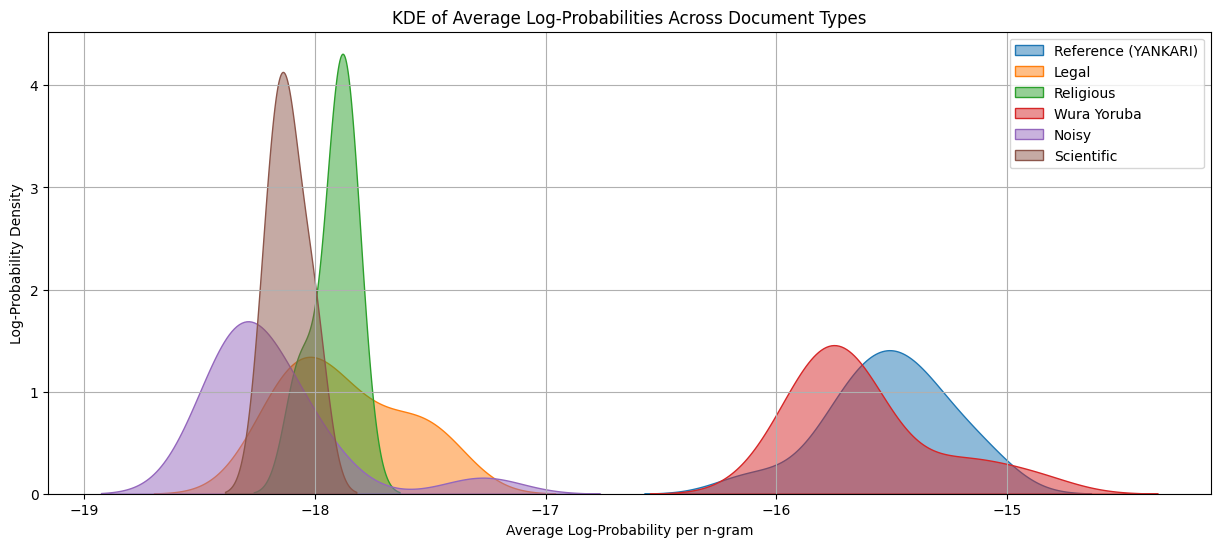

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))

score_data = [
    (rf_scores, 'Reference (YANKARI)'),
    (legal_scores, 'Legal'),
    (religious_scores, 'Religious'),
    (wura_scores, 'Wura Yoruba'),
    (noisy_scores, 'Noisy'),
    (sci_scores, 'Scientific'),
]
# Use a for loop to plot the score dat list
for scores, label in score_data:
    sns.kdeplot(scores, fill=True, label=label, alpha=0.5, ax=ax)

# Set labels and title
plt.xlabel('Average Log-Probability per n-gram(4)')
plt.ylabel('Log-Probability Density')  # Y-axis label
plt.title('KDE of Average Log-Probabilities Across Document Types')

# Show plot
plt.legend()
plt.grid(True)  
plt.show()

In [ ]:
#Compute average log-probability for each document in rf_text
rf_scores = get_avg_logprob(rf_text, ngram_probs_2,char_trigram_probs, n_value=2,smoothing=1e-8)
print(rf_scores[:5])

legal_scores = get_avg_logprob(legal_text, ngram_probs_2,char_trigram_probs, n_value=2,smoothing=1e-8)
print(legal_scores[:5])

religious_scores = get_avg_logprob(reli_text, ngram_probs_2,char_trigram_probs, n_value=2,smoothing=1e-8)
print(religious_scores[:5])

wura_scores = get_avg_logprob(wura_text, ngram_probs_2,char_trigram_probs, n_value=2,smoothing=1e-8)
print(wura_scores[:5])

noisy_scores = get_avg_logprob(noisy_text, ngram_probs_2,char_trigram_probs, n_value=2,smoothing=1e-8)
print(noisy_scores[:5])

sci_scores = get_avg_logprob(sci_text, ngram_probs_2,char_trigram_probs, n_value=2,smoothing=1e-8)
print(sci_scores[:5])

[-10.947141497118073, -11.182049620522328, -11.610918832883232, -11.4770013969779, -11.26554251792578]
[-11.821318359479786, -12.793161893429012, -13.37872468191196, -13.385795491671512, -12.454073480749482]
[-12.3175677817543, -12.496017964175607, -13.003123272351825, -12.271035482926438, -13.054268098714928]
[-12.471064681979223, -11.384794215154065, -10.419390383289514, -11.807103919676507, -11.30575643298745]
[-14.362044664533272, -14.904693692911188, -13.484689880220428, -14.45365569030089, -15.538318451414307]
[-13.786245535255363, -14.720579920602814, -14.625859575943428, -14.27170290789547]


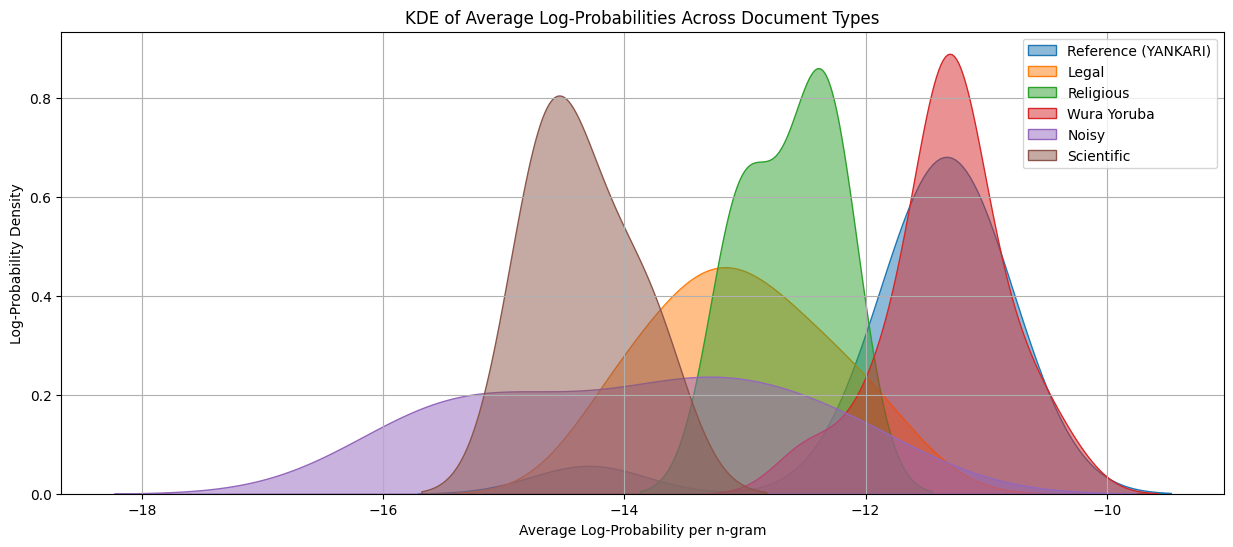

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))

score_data = [
    (rf_scores, 'Reference (YANKARI)'),
    (legal_scores, 'Legal'),
    (religious_scores, 'Religious'),
    (wura_scores, 'Wura Yoruba'),
    (noisy_scores, 'Noisy'),
    (sci_scores, 'Scientific'),
]
# Use a for loop to plot the score dat list
for scores, label in score_data:
    sns.kdeplot(scores, fill=True, label=label, alpha=0.5, ax=ax)

# Set labels and title
plt.xlabel('Average Log-Probability per n-gram(2)')
plt.ylabel('Log-Probability Density')  # Y-axis label
plt.title('KDE of Average Log-Probabilities Across Document Types')

# Show plot
plt.legend()
plt.grid(True)  
plt.show()